## Merge

In [43]:
import geopandas as gpd
import pandas as pd
import numpy as np
import scipy as sp

In [44]:
# 1. Lee los dos archivos shape
E14A23 = gpd.read_file("E14A23/conjunto_de_datos/curva_nivel50_l.shp")
E14A13 = gpd.read_file("E14A13/conjunto_de_datos/curva_nivel50_l.shp")



In [45]:
print("Columnas archivo 1:", E14A23.columns.tolist())
print("Columnas archivo 2:", E14A13.columns.tolist())


Columnas archivo 1: ['geografico', 'elevacion', 'tipo', 'codigo', 'cali_repr', 'carta', 'identifica', 'objectid', 'geometry']
Columnas archivo 2: ['geografico', 'elevacion', 'tipo', 'codigo', 'cali_repr', 'carta', 'identifica', 'objectid', 'geometry']


In [46]:
print("CRS archivo 1:", E14A23.crs)
print("CRS archivo 2:", E14A13.crs)

CRS archivo 1: EPSG:6369
CRS archivo 2: EPSG:6369


In [47]:
# 3. Fusión simple (concatena uno debajo del otro)
merge_curvas = gpd.GeoDataFrame(pd.concat([E14A23, E14A13], ignore_index=True), crs=E14A23.crs)

In [48]:
! mkdir morelia

In [49]:
# 4. Guarda el resultado
merge_curvas.to_file("morelia/merge_curvas_morelia.shp")

print("merge hecho")

merge hecho


## MDE

In [50]:
import numpy as np
import rasterio
from rasterio.transform import from_origin
from scipy.interpolate import griddata

In [51]:
#ver el contenido del shape en general
#print("\nPrimeras 5 filas:")
#print(merge_curvas.head())

#ver tipos de datos y fijarse en si hay altura, elevacion, height... Algo q sea de altura
print("\nTipos de datos:")
print(merge_curvas.dtypes)


Tipos de datos:
geografico         str
elevacion        int64
tipo               str
codigo             str
cali_repr          str
carta              str
identifica         str
objectid         int64
geometry      geometry
dtype: object


In [52]:
# Extraer coordenadas y valores de altura
import numpy as np

# Extraer coordenadas y valores de altura
coords = []
valores = []

for idx, row in merge_curvas.iterrows():
    line = row.geometry
    elev = row["elevacion"]
    
    # Extrae coordenadas de la línea
    puntos = list(line.coords)
    for punto in puntos:
        coords.append([punto[0], punto[1]])
        valores.append(elev)

coords = np.array(coords)
valores = np.array(valores)


In [53]:
# Definir límites del área para el raster
x_min, y_min, x_max, y_max = merge_curvas.total_bounds

# Definir resolución del DEM (en unidades del CRS, ejemplo: 10 metros)
resolucion = 10

# Crear grid
x_grid = np.arange(x_min, x_max, resolucion)
y_grid = np.arange(y_min, y_max, resolucion)
xx, yy = np.meshgrid(x_grid, y_grid)

# Interpolar
zz = griddata(coords, valores, (xx, yy), method='linear')



In [56]:
# Guardar como raster
with rasterio.open(
    'mde_morelia.tif',
    'w',
    driver='GTiff',
    height=zz.shape[0],
    width=zz.shape[1],
    count=1,
    dtype=zz.dtype,
    crs=curvas_fusionadas.crs,
    transform=from_origin(x_min, y_max, resolucion, resolucion),
) as dst:
    dst.write(zz, 1)

print("MDE generado")

MDE generado


## MDT


In [57]:
import rasterio
from scipy.ndimage import uniform_filter

In [60]:
def hillshade(dem, azimuth=315, angle_altitude=45):
    """
    Calcula hillshade a partir de un DEM
    """
    # Rellenar NaN temporalmente para calcular gradientes
    dem_filled = np.nan_to_num(dem, nan=0)
    
    # Calcular pendiente y orientación
    x, y = np.gradient(dem_filled)
    
    # Convertir a radianes
    azimuth_rad = np.radians(345 - azimuth + 90)
    alt_rad = np.radians(angle_altitude)
    
    # Pendiente en radianes
    slope = np.arctan(np.sqrt(x**2 + y**2))
    aspect = np.arctan2(-x, y)
    
    # Calcular hillshade
    hill = np.sin(alt_rad) * np.sin(slope) + \
           np.cos(alt_rad) * np.cos(slope) * np.cos(azimuth_rad - aspect)
    
    # Escalar de -1..1 a 0..255
    hill = 255 * ((hill + 1) / 2)
    
    # Donde originalmente había NaN, poner 0 (o 255 si prefieres blanco)
    hill = np.where(np.isnan(dem), 0, hill)
    hill = np.clip(hill, 0, 255).astype(np.uint8)
    
    return hill




In [62]:
with rasterio.open('mde_morelia.tif') as src:
    mde = src.read(1)
    perfil = src.profile

# Calcular hillshade
mdt = hillshade(mde)

# Actualizar perfil para 1 banda, uint8
perfil.update(dtype=rasterio.uint8, count=1, nodata=None)

# Guardar MDT (hillshade)
with rasterio.open('mdt.tif', 'w', **perfil) as dst:
    dst.write(mdt, 1)

print("MDT Generado")

MDT Generado


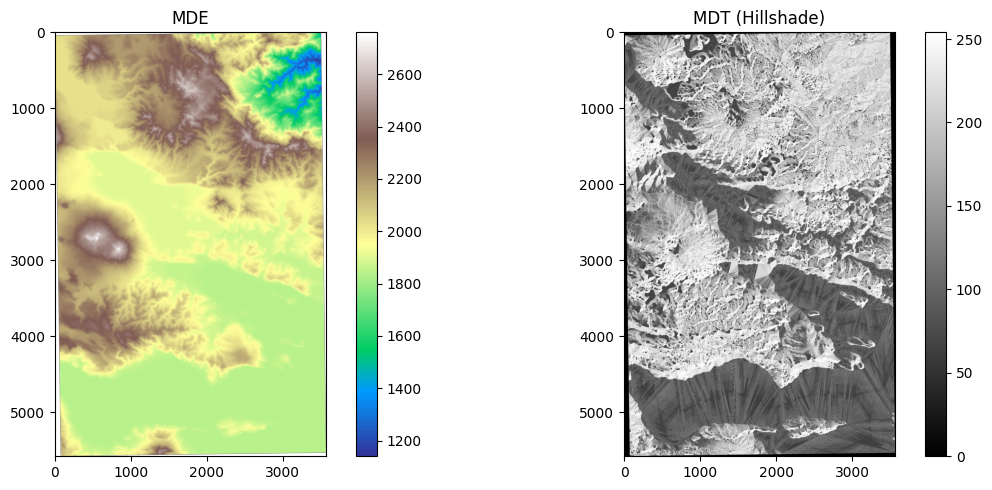

In [42]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

im1 = ax1.imshow(mde, cmap='terrain')
ax1.set_title('MDE')
plt.colorbar(im1, ax=ax1)

im2 = ax2.imshow(mdt, cmap='gray')
ax2.set_title('MDT (Hillshade)')
plt.colorbar(im2, ax=ax2)

plt.tight_layout()
plt.savefig('mde_vs_mdt.png', dpi=150)
plt.show()